# Домашнее задание 2.2. Задача трёх тел

**Уровень:** 🟢  
**Выполнил:** Константин Мурусидзе, 6 курс мехмата МГУ

Рассматривается плоское движение массивной звезды и двух лёгких планет.
Движение всех трёх тел рассчитывается методами RK4 и Верле для нескольких шагов.

## 1. Уравнения и начальные условия

В безразмерных единицах $G=1$. Ускорение каждого тела определяется притяжением двух остальных:

$$
\ddot{\mathbf r}_i=G\sum_{j\ne i}m_j
\frac{\mathbf r_j-\mathbf r_i}{|\mathbf r_j-\mathbf r_i|^3}.
$$

Массы: $m_0=1$, $m_1=0.001$, $m_2=0.002$.
Первоначально планеты находятся на расстояниях $1$ и $1.8$ от звезды.
Скорости направлены перпендикулярно радиусам и выбраны по формуле
$v_i=\sqrt{Gm_0/r_i}$.
Это приближение круговых орбит в поле звезды, а не точное решение задачи трёх тел.

После задания начальных условий из координат и скоростей вычитаются координата и скорость центра масс:

$$
\mathbf R=\frac{\sum_i m_i\mathbf r_i}{\sum_i m_i},
\qquad
\mathbf V=\frac{\sum_i m_i\mathbf v_i}{\sum_i m_i}.
$$

Так центр масс первоначально покоится в начале координат. Звезда не закрепляется:
её движение тоже входит в расчёт.

In [6]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 10, "axes.grid": True, "grid.alpha": 0.25})

G = 1.0
masses = np.array([1.0, 0.001, 0.002])
r0 = np.array([[0.0, 0.0], [1.0, 0.0], [0.0, 1.8]])
v0 = np.array([[0.0, 0.0], [0.0, 1.0], [-np.sqrt(G*masses[0]/1.8), 0.0]])

r0 -= np.sum(masses[:, None]*r0, axis=0) / masses.sum()
v0 -= np.sum(masses[:, None]*v0, axis=0) / masses.sum()

T1 = 2*np.pi  # приближённый период внутренней планеты
t_end = 10*T1
steps_per_period = [50, 100, 200]


## 2. Методы RK4 и Верле

Для RK4 используется система первого порядка $\dot{\mathbf r}=\mathbf v$,
$\dot{\mathbf v}=\mathbf a(\mathbf r)$.

Для скоростного варианта метода Верле:

$$
\mathbf r_{n+1}=\mathbf r_n+h\mathbf v_n+\frac{h^2}{2}\mathbf a_n,
\qquad
\mathbf v_{n+1}=\mathbf v_n+\frac h2(\mathbf a_n+\mathbf a_{n+1}).
$$

Шаги равны $h=T_1/50$, $T_1/100$, $T_1/200$.
Для всех расчётов используется один и тот же интервал времени $0\le t\le10T_1$.

In [7]:
def acceleration(r):
    a = np.zeros_like(r)
    for i in range(3):
        for j in range(i + 1, 3):
            delta = r[j] - r[i]
            distance = np.linalg.norm(delta)
            pair = G*delta / distance**3
            a[i] += masses[j]*pair
            a[j] -= masses[i]*pair
    return a


def rhs(state):
    r, v = state
    return np.stack((v, acceleration(r)))


def rk4_step(r, v, h):
    state = np.stack((r, v))
    k1 = rhs(state)
    k2 = rhs(state + h*k1/2)
    k3 = rhs(state + h*k2/2)
    k4 = rhs(state + h*k3)
    new_state = state + h*(k1 + 2*k2 + 2*k3 + k4)/6
    return new_state[0], new_state[1]


def verlet_step(r, v, h):
    a_old = acceleration(r)
    r_new = r + h*v + 0.5*h*h*a_old
    a_new = acceleration(r_new)
    v_new = v + 0.5*h*(a_old + a_new)
    return r_new, v_new


def integrate(stepper, n_per_period):
    n_steps = 10*n_per_period
    time = np.linspace(0.0, t_end, n_steps + 1)
    h = t_end/n_steps
    positions = np.empty((n_steps + 1, 3, 2))
    velocities = np.empty_like(positions)
    positions[0], velocities[0] = r0, v0

    for n in range(n_steps):
        positions[n + 1], velocities[n + 1] = stepper(
            positions[n], velocities[n], h
        )
    return time, positions, velocities


methods = {"RK4": rk4_step, "Verlet": verlet_step}
solutions = {}
for method_name, stepper in methods.items():
    for n_per_period in steps_per_period:
        solutions[(method_name, n_per_period)] = integrate(stepper, n_per_period)


## 3. Траектории в системе центра масс

В каждой точке времени из координат тел вычитается вычисленный центр масс.
На всех панелях одинаковый масштаб. Движение звезды мало из-за её большой массы,
но оно рассчитывается, а не задаётся постоянным.

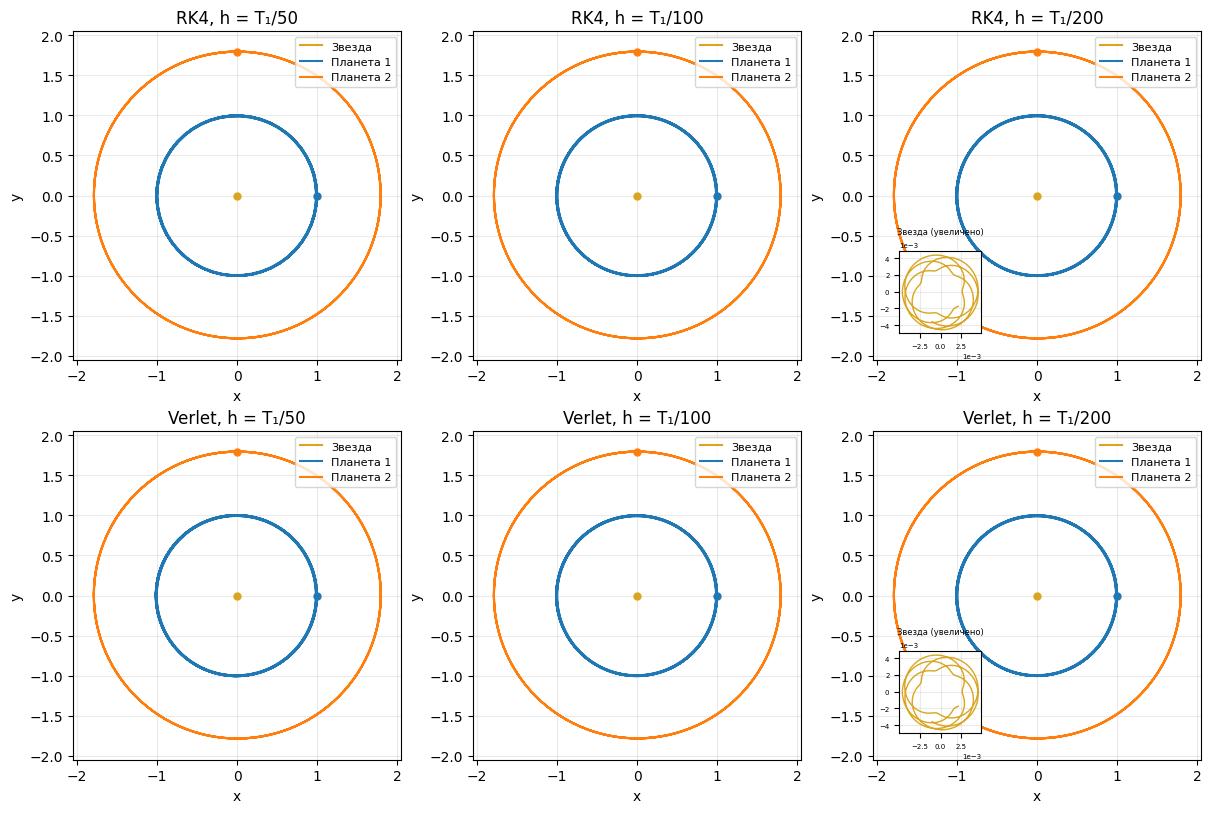

In [8]:
def center_of_mass_frame(positions, velocities):
    R = np.sum(masses[None, :, None]*positions, axis=1) / masses.sum()
    V = np.sum(masses[None, :, None]*velocities, axis=1) / masses.sum()
    return positions - R[:, None, :], velocities - V[:, None, :]


colors = ["goldenrod", "tab:blue", "tab:orange"]
labels = ["Звезда", "Планета 1", "Планета 2"]
fig, axes = plt.subplots(2, 3, figsize=(12, 8), constrained_layout=True)

for row, method_name in enumerate(methods):
    for col, n_per_period in enumerate(steps_per_period):
        ax = axes[row, col]
        time, positions, velocities = solutions[(method_name, n_per_period)]
        r, _ = center_of_mass_frame(positions, velocities)
        for i in range(3):
            ax.plot(r[:, i, 0], r[:, i, 1], color=colors[i], label=labels[i])
            ax.scatter(r[0, i, 0], r[0, i, 1], color=colors[i], s=25, zorder=4)
        ax.set_title(f"{method_name}, h = T₁/{n_per_period}")
        ax.set_xlim(-2.05, 2.05)
        ax.set_ylim(-2.05, 2.05)
        ax.set_aspect("equal")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.legend(loc="upper right", fontsize=8)

        if n_per_period == steps_per_period[-1]:
            inset = ax.inset_axes([0.08, 0.08, 0.25, 0.25])
            inset.plot(r[:, 0, 0], r[:, 0, 1], color=colors[0], lw=1)
            inset.set_aspect("equal", adjustable="datalim")
            inset.set_title("Звезда (увеличено)", fontsize=6)
            inset.tick_params(labelsize=5)
            inset.ticklabel_format(axis="both", style="sci", scilimits=(0, 0), useOffset=False)
            inset.xaxis.get_offset_text().set_fontsize(5)
            inset.yaxis.get_offset_text().set_fontsize(5)

plt.show()


## 4. Полная энергия и момент импульса

В системе центра масс:

$$
E=\frac12\sum_i m_i|\mathbf v_i|^2
-G\sum_{i<j}\frac{m_im_j}{|\mathbf r_i-\mathbf r_j|},
\qquad
L_z=\sum_i m_i(x_i v_{y,i}-y_i v_{x,i}).
$$

Энергия включает взаимодействия всех трёх пар тел.
Для точного решения $E$ и $L_z$ постоянны.
Чтобы небольшие численные отклонения были видны, на графиках показаны
$(E(t)-E(0))/|E(0)|$ и $(L_z(t)-L_z(0))/|L_z(0)|$.

Метод              h      max |ΔE|/|E₀|      max |ΔL|/|L₀|
RK4         0.125664       2.616485e-05       7.591799e-06
RK4         0.062832       8.146436e-07       2.366977e-07
RK4         0.031416       2.538999e-08       7.396702e-09
Verlet      0.125664       6.384490e-05       1.415356e-15
Verlet      0.062832       1.137932e-05       1.651249e-15
Verlet      0.031416       2.820536e-06       3.302497e-15


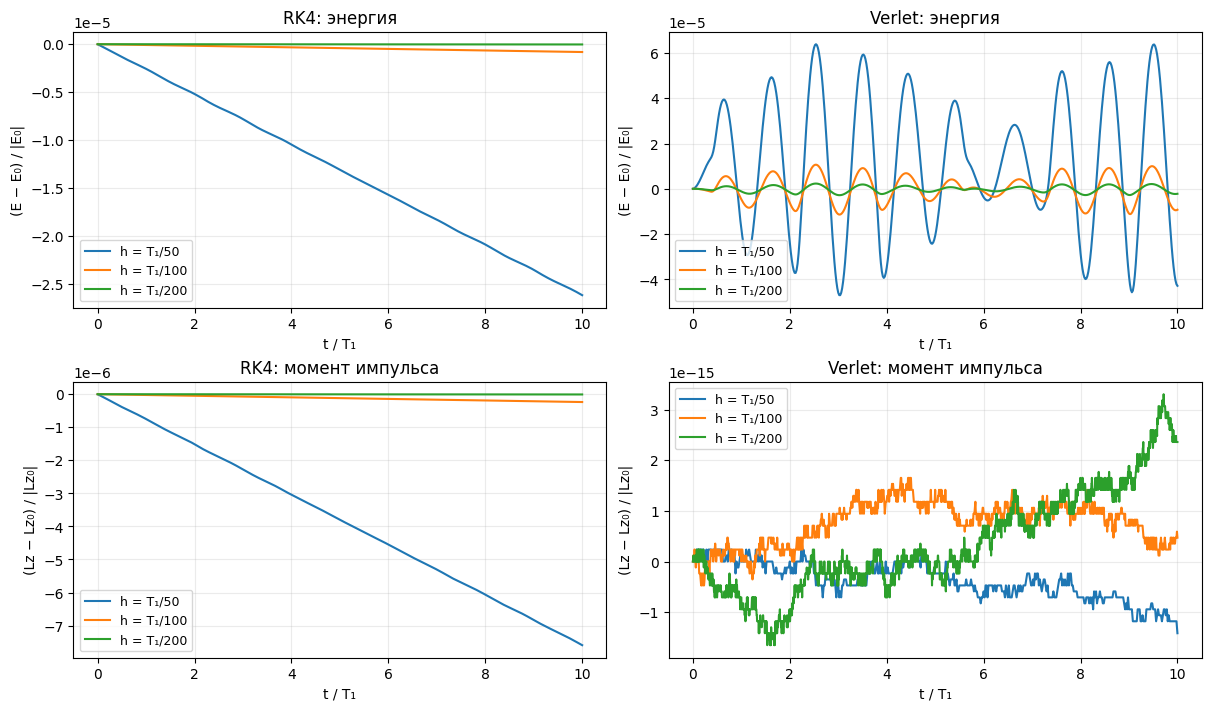

In [9]:
def total_energy(r, v):
    kinetic = 0.5*np.sum(masses[None, :, None]*v**2, axis=(1, 2))
    potential = np.zeros(len(r))
    for i in range(3):
        for j in range(i + 1, 3):
            distance = np.linalg.norm(r[:, j] - r[:, i], axis=1)
            potential -= G*masses[i]*masses[j]/distance
    return kinetic + potential


def total_angular_momentum(r, v):
    cross = r[:, :, 0]*v[:, :, 1] - r[:, :, 1]*v[:, :, 0]
    return np.sum(masses[None, :]*cross, axis=1)


diagnostics = {}
print(f"{'Метод':<9} {'h':>10} {'max |ΔE|/|E₀|':>18} {'max |ΔL|/|L₀|':>18}")
for method_name in methods:
    for n_per_period in steps_per_period:
        time, positions, velocities = solutions[(method_name, n_per_period)]
        r, v = center_of_mass_frame(positions, velocities)
        E = total_energy(r, v)
        L = total_angular_momentum(r, v)
        dE = (E - E[0])/abs(E[0])
        dL = (L - L[0])/abs(L[0])
        diagnostics[(method_name, n_per_period)] = (E, L, dE, dL)
        print(f"{method_name:<9} {T1/n_per_period:10.6f} "
              f"{np.max(np.abs(dE)):18.6e} {np.max(np.abs(dL)):18.6e}")

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
for col, method_name in enumerate(methods):
    for n_per_period in steps_per_period:
        time = solutions[(method_name, n_per_period)][0]
        E, L, dE, dL = diagnostics[(method_name, n_per_period)]
        label = f"h = T₁/{n_per_period}"
        axes[0, col].plot(time/T1, dE, label=label)
        axes[1, col].plot(time/T1, dL, label=label)
    axes[0, col].set_title(f"{method_name}: энергия")
    axes[1, col].set_title(f"{method_name}: момент импульса")
    axes[0, col].set_ylabel("(E − E₀) / |E₀|")
    axes[1, col].set_ylabel("(Lz − Lz₀) / |Lz₀|")
    for ax in axes[:, col]:
        ax.set_xlabel("t / T₁")
        ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0), useOffset=False)
        ax.legend(fontsize=9)

plt.show()


## 5. Выводы

1. Оба метода воспроизводят движение двух планет вокруг звезды.
   Орбиты близки к круговым, но не совпадают с ними точно из-за взаимного притяжения планет
   и движения звезды.
2. При уменьшении шага максимальное относительное отклонение энергии уменьшается
   для обоих методов. При одинаковом шаге в этом расчёте RK4 точнее по энергии.
3. У RK4 заметен небольшой накопленный дрейф энергии, а у Верле отклонение энергии
   в основном колеблется. Вывод относится к выбранным начальным условиям и интервалу $10T_1$.
4. Скоростной метод Верле сохраняет полный момент импульса с точностью округления.
   У RK4 отклонение момента импульса уменьшается при уменьшении шага.